In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [4]:
df = pd.read_csv("data\\facebook_ads_feature_engineered.csv")

In [5]:
df.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,impressions,clicks,spent,Total_Conversion,Approved_Conversion,CTR,CPC,CPM,Conversion_rate,Approved_Conversion_Rate,CPA,Cost_Per_Approved,Conversions_per_1000
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1,0.013605,1.43,0.194558,200.0,50.0,0.715,1.43,0.272109
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0,0.011198,0.91,0.101898,100.0,0.0,0.910,0.00,0.111976
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0,0.000000,0.00,0.000000,0.0,0.0,0.000,0.00,1.443001
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0,0.023480,1.25,0.293496,100.0,0.0,1.250,0.00,0.234797
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1,0.024195,1.29,0.312122,100.0,100.0,1.290,1.29,0.241955


In [6]:
df.shape

(1143, 19)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ad_id                     1143 non-null   int64  
 1   xyz_campaign_id           1143 non-null   int64  
 2   fb_campaign_id            1143 non-null   int64  
 3   age                       1143 non-null   object 
 4   gender                    1143 non-null   object 
 5   interest                  1143 non-null   int64  
 6   impressions               1143 non-null   int64  
 7   clicks                    1143 non-null   int64  
 8   spent                     1143 non-null   float64
 9   Total_Conversion          1143 non-null   int64  
 10  Approved_Conversion       1143 non-null   int64  
 11  CTR                       1143 non-null   float64
 12  CPC                       1143 non-null   float64
 13  CPM                       1143 non-null   float64
 14  Conversi

In [8]:
df.describe()

,ad_id,xyz_campaign_id,fb_campaign_id,interest,impressions,clicks,spent,Total_Conversion,Approved_Conversion,CTR,CPC,CPM,Conversion_rate,Approved_Conversion_Rate,CPA,Cost_Per_Approved,Conversions_per_1000
count,1.143000e+03,1143.000000,1143.000000,1143.000000,1.143000e+03,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,9.872611e+05,1067.382327,133783.989501,32.766404,1.867321e+05,33.390201,51.360656,2.855643,0.944007,0.016420,1.227812,0.239387,24.169930,33.670667,16.016721,20.719900,0.252510
std,1.939928e+05,121.629393,20500.308622,26.952131,3.127622e+05,56.892438,86.908418,4.483593,1.737708,0.011506,0.614889,0.160908,36.838128,40.114345,24.297504,43.761027,0.712050
min,7.087460e+05,916.000000,103916.000000,2.000000,8.700000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.776325e+05,936.000000,115716.000000,16.000000,6.503500e+03,1.000000,1.480000,1.000000,0.000000,0.010022,1.234500,0.148742,2.857143,0.000000,1.380000,0.000000,0.012122
50%,1.121185e+06,1178.000000,144549.000000,25.000000,5.150900e+04,8.000000,12.370000,1.000000,1.000000,0.015981,1.450000,0.248816,9.090909,15.384615,8.190000,0.000000,0.030699
75%,1.121804e+06,1178.000000,144657.500000,31.000000,2.217690e+05,37.500000,60.025000,3.000000,1.000000,0.023364,1.600000,0.332700,25.000000,54.545455,21.229286,24.075000,0.169406
max,1.314415e+06,1178.000000,179982.000000,114.000000,3.052003e+06,421.000000,639.949998,60.000000,21.000000,0.105932,2.212000,1.504237,400.000000,100.000000,332.989999,352.449999,11.494253


In [9]:
df.isnull().sum()

ad_id                       0
xyz_campaign_id             0
fb_campaign_id              0
age                         0
gender                      0
interest                    0
impressions                 0
clicks                      0
spent                       0
Total_Conversion            0
Approved_Conversion         0
CTR                         0
CPC                         0
CPM                         0
Conversion_rate             0
Approved_Conversion_Rate    0
CPA                         0
Cost_Per_Approved           0
Conversions_per_1000        0
dtype: int64

# Encoding Categorical values

In [10]:
le = LabelEncoder()

df['age_encoded'] = le.fit_transform(df['age'])
df['gender_encoded'] = le.fit_transform(df['gender'])

In [11]:
df.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,impressions,clicks,spent,Total_Conversion,...,CTR,CPC,CPM,Conversion_rate,Approved_Conversion_Rate,CPA,Cost_Per_Approved,Conversions_per_1000,age_encoded,gender_encoded
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,...,0.013605,1.43,0.194558,200.0,50.0,0.715,1.43,0.272109,0,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,...,0.011198,0.91,0.101898,100.0,0.0,0.910,0.00,0.111976,0,1
2,708771,916,103920,30-34,M,20,693,0,0.00,1,...,0.000000,0.00,0.000000,0.0,0.0,0.000,0.00,1.443001,0,1
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,...,0.023480,1.25,0.293496,100.0,0.0,1.250,0.00,0.234797,0,1
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,...,0.024195,1.29,0.312122,100.0,100.0,1.290,1.29,0.241955,0,1


# Train Test Split

In [15]:
X = df.drop(columns=['age','gender','Approved_Conversion'])

y = df['Approved_Conversion']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("Training Shape", X_train.shape)
print("Testing Shape", X_test.shape)

Training Shape (914, 18)
Testing Shape (229, 18)


# Linear Regression

In [16]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [17]:

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE :", lr_rmse)
print("R2 :", lr_r2)

Linear Regression
MAE : 0.3442461438542047
RMSE : 0.6741981982983737
R2 : 0.8615336773794302


# Decision tree Regressor

In [18]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree")
print("MAE :", dt_mae)
print("RMSE :", dt_rmse)
print("R2 :", dt_r2)

Decision Tree
MAE : 0.08733624454148471
RMSE : 0.5528805077909661
R2 : 0.9068824499848968


# Random forest Regressor

In [19]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R2 :", rf_r2)

Random Forest
MAE : 0.08633187772925763
RMSE : 0.5635955609582795
R2 : 0.9032381616399842


# XGBoost Regreesor

In [20]:
xgb = XGBRegressor(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost")
print("MAE :", xgb_mae)
print("RMSE :", xgb_rmse)
print("R2 :", xgb_r2)

XGBoost
MAE : 0.07615846159019166
RMSE : 0.5982709634205359
R2 : 0.8909652829170227


# Compare models

In [21]:
results = pd.DataFrame({
    'Model':[
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'MAE':[
        lr_mae,
        dt_mae,
        rf_mae,
        xgb_mae
    ],
    'RMSE':[
        lr_rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse
    ],
    'R2 Score':[
        lr_r2,
        dt_r2,
        rf_r2,
        xgb_r2
    ]
})

results.sort_values(
    by='R2 Score',
    ascending=False,
    inplace=True
)

results

,Model,MAE,RMSE,R2 Score
1,Decision Tree,0.087336,0.552881,0.906882
2,Random Forest,0.086332,0.563596,0.903238
3,XGBoost,0.076158,0.598271,0.890965
0,Linear Regression,0.344246,0.674198,0.861534


# Actual vs Predicted

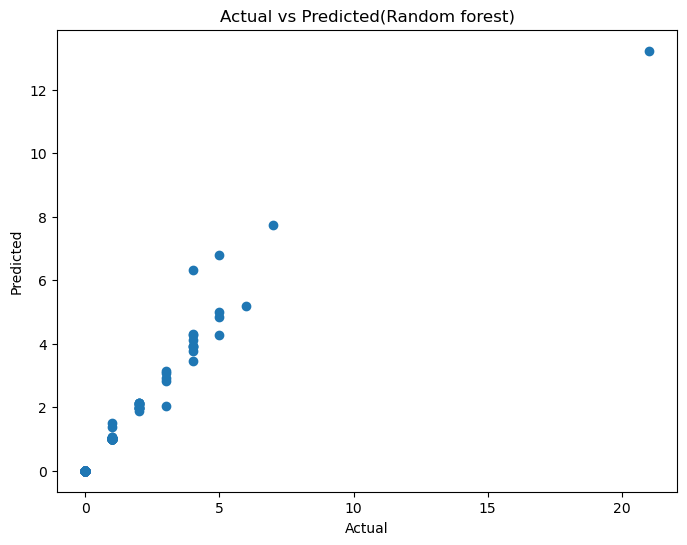

In [31]:
# Random forest

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted(Random forest)")

plt.show()

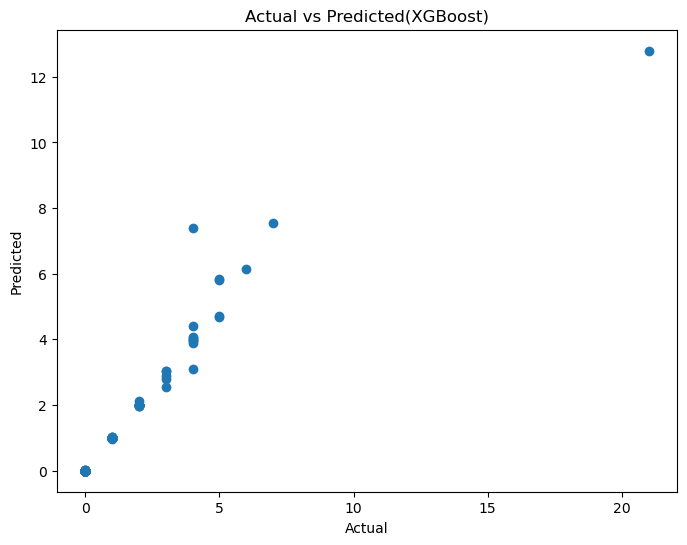

In [30]:
# XGBoost

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    xgb_pred,
    label='Data'
)


plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted(XGBoost)")

plt.show()

# Cross Validation

In [38]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)

print("Average R2 :", scores.mean())

[0.98465588 0.9991522  0.79608102 0.959346   0.88550385]
Average R2 : 0.9249477903555985


# Hyperparameter Tuning

In [36]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 300}
0.9111464666326399


# Train Best Model

In [37]:
best_rf = grid.best_estimator_

best_rf.fit(X_train,y_train)

best_pred = best_rf.predict(X_test)

print("R2 :", r2_score(y_test,best_pred))

R2 : 0.9064383383935787


# Save model

In [40]:
import joblib

joblib.dump(best_rf,'model\\facebook_ads_model.pkl')

print("Model Saved Successfully")

Model Saved Successfully


# Sample test

In [41]:
sample = X_test.iloc[:5]

prediction = best_rf.predict(sample)

pd.DataFrame({
    'Actual': y_test.iloc[:5].values,
    'Predicted': prediction
})

,Actual,Predicted
0,1,1.000000
1,1,1.006667
2,0,0.000000
3,1,1.000000
4,0,0.000000
